In [170]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from scipy.stats import bootstrap

# FILEPATH = '/scratch/nte5cp' 
FILEPATH = '/Users/a404/attention-brokers-bsky'
HANDLE = 'pfrazee.com'
df = pd.read_csv(f'{FILEPATH}/interpolated_did_csvs/{HANDLE}.csv')
denoms = json.load(open('handles_to_foll_population.json', 'r'))[HANDLE]
DENOM_FOL = denoms['foll']
DENOM_NON = denoms['non']

if DENOM_FOL == 1 or DENOM_NON == 1:
    TITLE = f'mean raw follow counts for {HANDLE}'
else:
    TITLE = f'mean per-capita follow counts for {HANDLE}'

In [171]:
df.head()

,Unnamed: 0,unit_id,ever_treated,ts,gain_rate,time_period
0,0,0,False,-14,0.0,627.0
1,1,0,False,-13,0.0,628.0
2,2,0,False,-12,0.0,629.0
3,3,0,False,-11,1.0,630.0
4,4,0,False,-10,1.0,631.0


In [172]:
def plot_cis_and_means(df, color='red', label='AB_foll', denom=DENOM_FOL):
    """
    Given a dataframe of per-day per-reposted-account follow counts, 
    plot the mean and 95% bootstrapped CI of the per-day per-capita following rate.

    Inputs:
        df: dataframe with columns ts (in range(-14, 14)) and gain_rate
        color: color of the shaded CI + mean plot for this dataframe's data
        label: label of this dataset in the legend
        denom: denominator to calculate per-capita following rates.

    Outputs:
        Doesn't return anything; just plots the mean + CI.
    """
    ci_lows = []
    means = []
    ci_highs = []

    # for each day relative to repost, obtain the mean per-capita follower accumulation
    # as well as the 95% confidence interval on the mean.
    for ix in range(-14, 14):
        gain_rate = df[df.ts == ix]['gain_rate'] / denom # normalize by population
        mean = gain_rate.mean()
        ci_low, ci_high = bootstrap(
            (np.array(gain_rate.to_list()),), 
            np.mean,
            confidence_level=0.95,
        ).confidence_interval
        ci_lows.append(ci_low)
        ci_highs.append(ci_high)
        means.append(mean)

    # fill in follower CI
    plt.fill_between(
        [i for i in range(-14, 14)],
        ci_lows,
        ci_highs,
        color=color,
        alpha=0.3,
    )
    # plot mean on top of CI
    plt.plot(
        [i for i in range(-14, 14)],
        means,
        color=color,
        label=label,
    )


/Users/a404/mamba/envs/phys7332/lib/python3.13/site-packages/scipy/stats/_resampling.py:155: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/a404/mamba/envs/phys7332/lib/python3.13/site-packages/scipy/_lib/_util.py:365: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


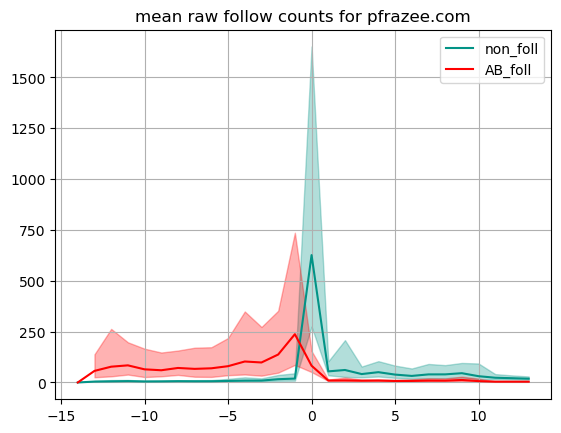

In [173]:
df_foll = df[df['ever_treated']]
df_non = df[~df['ever_treated']]
plot_cis_and_means(df_non, 'xkcd:teal', 'non_foll', DENOM_NON)
plot_cis_and_means(df_foll, 'red', 'AB_foll', DENOM_FOL)
plt.legend()
plt.title(TITLE)
plt.grid()
plt.savefig(f'{FILEPATH}/plots/{HANDLE}_trends.png')

In [148]:
# make dataframe for DiD analysis
df_non['gain_rate'] = df_non['gain_rate'] / DENOM_NON
df_foll['gain_rate'] = df_foll['gain_rate'] / DENOM_FOL

df_wide = pd.merge(
    df_non, 
    df_foll, 
    left_on=['unit_id', 'ts'], 
    right_on=['unit_id', 'ts'], 
    suffixes=['_non', '_fol']
)
df_wide['period'] = df_wide['time_period_non']
df_wide['post.treat'] = df_wide['ts'].apply(lambda b: b >= 0)
df_wide = df_wide[['period', 'post.treat', 'unit_id', 'gain_rate_fol', 'gain_rate_non', 'ts']]
df_wide.to_csv(f'{FILEPATH}/processed_did_csvs/{HANDLE}_processed_did_data.csv')


/var/folders/8f/h3kcldy50kx99114fyyq93k00000gn/T/ipykernel_79281/2962079341.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non['gain_rate'] = df_non['gain_rate'] / DENOM_NON
/var/folders/8f/h3kcldy50kx99114fyyq93k00000gn/T/ipykernel_79281/2962079341.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_foll['gain_rate'] = df_foll['gain_rate'] / DENOM_FOL


In [149]:
df_wide

,period,post.treat,unit_id,gain_rate_fol,gain_rate_non,ts
0,719.0,False,0,0.000000,0.000000e+00,-14
1,720.0,False,0,0.000010,4.266659e-07,-13
2,721.0,False,0,0.000013,4.266659e-07,-12
3,722.0,False,0,0.000013,0.000000e+00,-11
4,723.0,False,0,0.000011,0.000000e+00,-10
...,...,...,...,...,...,...
43703,792.0,True,1561,0.000010,4.266659e-07,9
43704,793.0,True,1561,0.000031,1.279998e-06,10
43705,794.0,True,1561,0.000017,8.533319e-07,11
43706,795.0,True,1561,0.000011,1.279998e-06,12
